# 1 - MCP and tool orchestration (four ways)

Same retrieval task, four **wiring** patterns in `src/mcp_demo/clients/`. The interesting question isn't "which is best" — it's **what does each layer of autonomy cost you, and when is the cost worth paying?**

| client | what the model gets | autonomy |
|---|---|---|
| `direct` | three `@tool` functions in-process | low |
| `via_mcp` | same three tools behind a FastMCP stdio server | low |
| `via_programmatic` | one `execute_python` tool; BM25 / dense / rerank pre-bound in the REPL | medium |
| `via_coding_agent` | shell + filesystem + embedded `SKILL.md`; nothing pre-imported | high |

## Bake-off design

12 questions across three difficulty tiers × 5 reps × 4 clients = **240 trajectories**.

- **`easy`** (4q) — single-hop lookups. All clients should pass.
- **`medium`** (4q) — multi-hop / synthesis. Rewards ≥2 retrievals.
- **`hard`** (4q) — planning, arithmetic, and *honest refusal* (`h2` asks about Self-RAG, which is deliberately not in the corpus).

The hard tier is what makes the experiment honest. Easy questions can't separate architectures; you only see the cost of autonomy when the task starts to demand it.

## How to run

1. **`via_coding_agent` smoke tests** — pre-flight that catches infra regressions (corpus-path resolution, shell-command cap, recursion limit).
2. **Optional CSV cleanup** — drop only `via_coding_agent` rows to refill them after a code change without re-running the other 180 trajectories.
3. **Bake-off loop** — appends to `data/mcp_orchestration.csv`, resume-safe via `(client, query_id, run_idx)`.
4. **Analysis** — overall summary, by-difficulty table, two boxplot grids, cost/latency Pareto scatter.


In [1]:
import _path_setup  # noqa: F401

import os
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY"), "set OPENROUTER_API_KEY in .env"

from mcp_demo import tools
from mcp_demo.clients import direct, via_mcp, via_programmatic, via_coding_agent
from shared import judge_with_rubric

DATA = Path("data")
DATA.mkdir(exist_ok=True)
RESULTS_CSV = DATA / "mcp_orchestration.csv"

MODEL_SLUG = "anthropic/claude-sonnet-4.5"

# (qid, question, difficulty). Difficulty tiers stress different parts of the stack:
#   easy   — single-hop lookup; everyone should pass.
#   medium — multi-hop comparison / synthesis; rewards >=2 retrievals.
#   hard   — planning, computation, or "say no" when the corpus is silent.
QUESTIONS = [
    # --- easy: single-hop lookups ---
    ("e1", "What is hybrid retrieval and how does RRF combine BM25 with dense scores?", "easy"),
    ("e2", "How does cross-encoder reranking differ from a bi-encoder?", "easy"),
    ("e3", "Define reciprocal rank fusion (RRF) and what problem it solves.", "easy"),
    ("e4", "What problem does query decomposition solve in multi-hop RAG?", "easy"),
    # --- medium: multi-hop / synthesis ---
    ("m1", "Compare cross-encoder reranking with RRF: when would you pick one over the other? Cite tradeoffs.", "medium"),
    ("m2", "Walk through a hybrid RAG pipeline end-to-end: which step does each component own (sparse retrieval, dense retrieval, fusion, reranking)?", "medium"),
    ("m3", "What are the tradeoffs between increasing top-k vs. adding a cross-encoder reranker? Discuss latency, cost, and recall.", "medium"),
    ("m4", "How does ColBERT's late-interaction differ from a standard bi-encoder dense retriever, and what does it buy you?", "medium"),
    # --- hard: planning / computation / honest refusal ---
    ("h1", "Find passages in the corpus that critique purely-dense retrieval (e.g. lexical mismatch, OOV terms) and summarize the strongest critique. Quote at least one passage.", "hard"),
    ("h2", "Does the corpus describe the Self-RAG method? If not, say so explicitly and do NOT fabricate details. If yes, summarize it.", "hard"),
    ("h3", "Estimate the per-query rerank cost for top-k=20 vs top-k=100 if the cross-encoder costs $0.001 per document scored. Show your arithmetic and state which is cheaper.", "hard"),
    ("h4", "Build a 5-step plan a junior engineer could follow to add a reranker to an existing BM25-only system. For each step, cite a concrete corpus passage that supports it.", "hard"),
]
N_RUNS = 5
CLIENTS = ["direct", "via_mcp", "via_programmatic", "via_coding_agent"]
print(f"{len(QUESTIONS)} questions x {N_RUNS} runs x {len(CLIENTS)} clients = {len(QUESTIONS)*N_RUNS*len(CLIENTS)} trajectories")


/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


12 questions x 5 runs x 4 clients = 240 trajectories


In [2]:
q = "What is hybrid retrieval?"

bm = tools.bm25_search(q, k=3)
ds = tools.dense_search(q, k=3)
print("bm25_search ->", len(bm), "hits; first:", bm[0]["title"], "|", bm[0]["text"][:80])
print("dense_search ->", len(ds), "hits; first:", ds[0]["title"], "|", ds[0]["text"][:80])

rr = tools.rerank(q, bm + ds, top_k=3)
print("rerank ->", len(rr), "hits; top:", rr[0]["title"], "score=", round(rr[0]["score"], 3))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20168.69it/s]


bm25_search -> 3 hits; first: Information retrieval | [source: wikipedia | title: Information retrieval]

2022: The BEIR benchmark is 
dense_search -> 3 hits; first: Large language model | [source: wikipedia | title: Large language model]

=== Retrieval-augmented gener


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6890.22it/s]


rerank -> 3 hits; top: Retrieval-augmented generation score= 3.074


In [3]:
smoke_q = "What is hybrid retrieval and how does RRF combine BM25 with dense scores?"

for client_name, runner in [
    ("direct", lambda: direct.run(smoke_q, model_slug=MODEL_SLUG)),
    ("via_mcp", lambda: via_mcp.run(smoke_q, model_slug=MODEL_SLUG)),
    ("via_programmatic", lambda: via_programmatic.run(smoke_q, model_slug=MODEL_SLUG)),
    ("via_coding_agent", lambda: via_coding_agent.run(smoke_q, model_slug=MODEL_SLUG)),
]:
    t0 = time.time()
    try:
        r = runner()
        print(f"\n=== {client_name} ===")
        print(f"  tool_calls={r.n_tool_calls}  latency={r.total_latency_s:.1f}s  cost=${r.cost_usd:.4f}")
        print(f"  answer[:300]: {str(r.answer)[:300]}")
    except Exception as exc:  # noqa: BLE001
        print(f"\n=== {client_name} === FAILED in {time.time()-t0:.1f}s: {type(exc).__name__}: {exc}")



=== direct ===
  tool_calls=3  latency=49.0s  cost=$0.1156
  answer[:300]: Based on the search results, I can provide information about hybrid retrieval, though the specific details about RRF (Reciprocal Rank Fusion) are not fully covered in the retrieved documents. Let me provide what I found:

## Hybrid Retrieval

**Hybrid retrieval** is an approach that combines two com

=== via_mcp ===
  tool_calls=4  latency=80.6s  cost=$0.1867
  answer[:300]: Based on the search results, I can provide you with information about hybrid retrieval and how different methods combine BM25 with dense scores. However, I should note that while the documents discuss hybrid retrieval and data fusion methods in general, they don't provide specific details about the 

=== via_programmatic ===
  tool_calls=5  latency=35.9s  cost=$0.0825
  answer[:300]: Based on my search results, I can now provide you with a comprehensive answer about hybrid retrieval and RRF.

## Answer

**Hybrid Retrieval** is an informatio

In [4]:
# --- via_coding_agent smoke tests ---
# Run this BEFORE the full bake-off (cell below). Four single runs, ~5-10 min total.
# Catches infra regressions (corpus path, shell-command cap, recursion limit) so you
# don't waste an hour discovering them inside the 240-trajectory sweep.

import importlib
from mcp_demo.clients import via_coding_agent
importlib.reload(via_coding_agent)  # pick up edits without restarting the kernel


def _smoke(name, q, *, must_contain=None, must_not_start=None,
           min_tools=None, min_quality=None):
    r = via_coding_agent.run(q, model_slug=MODEL_SLUG)
    print(f"\n[{name}] tools={r.n_tool_calls}  latency={r.total_latency_s:.1f}s  "
          f"cost=${r.cost_usd:.3f}")
    print("  " + (r.answer[:300] or "").replace("\n", " "))
    if must_contain:
        missing = [t for t in must_contain if t.lower() not in r.answer.lower()]
        assert not missing, f"{name}: answer missing {missing!r}"
    if must_not_start:
        assert not r.answer.lower().startswith(must_not_start.lower()), \
            f"{name}: answer starts with bailout text"
    if min_tools is not None:
        assert r.n_tool_calls >= min_tools, \
            f"{name}: only {r.n_tool_calls} tool calls (expected >= {min_tools})"
    if min_quality is not None:
        rb = judge_with_rubric(question=q, answer=r.answer, reference="", evidence=None)
        print(f"  rubric overall={rb.overall:.2f}")
        assert rb.overall >= min_quality, \
            f"{name}: rubric overall={rb.overall} (expected >= {min_quality})"
    return r


# A. Path/env smoke. Symlink should make repo-relative paths resolve.
_smoke("env",
       "Run `ls -la notebooks/data/` and report exactly what you see.",
       must_contain=["bm25_index.pkl", "chroma_db"],
       must_not_start="sorry, need more steps")

# B. Easy question end-to-end. Validates symlink + budgets + recursion together.
_smoke("easy_e1",
       "What is hybrid retrieval and how does RRF combine BM25 with dense scores?",
       must_not_start="sorry, need more steps",
       min_tools=2, min_quality=3.5)

# C. Honest refusal on h2 — must actually search before refusing.
_smoke("hard_h2",
       "Does the corpus describe the Self-RAG method? If not, say so explicitly and do NOT fabricate.",
       must_contain=["self-rag", "not"],
       min_tools=3,
       must_not_start="sorry, need more steps")

# D. Arithmetic (no corpus needed) — sanity check on reasoning, not infra.
_smoke("hard_h3",
       "Estimate the per-query rerank cost for top-k=20 vs top-k=100 if the cross-encoder costs $0.001 per document scored. Show your arithmetic.",
       min_quality=3.0,
       must_not_start="sorry, need more steps")

print("\nAll smoke tests passed. Safe to run the full bake-off below.")



[env] tools=1  latency=9.7s  cost=$0.022
  Here's exactly what I see in `notebooks/week1/data/`:  ``` total 11384 drwxr-xr-x@ 10 sinanozdemir  staff      320 Apr 29 14:09 . drwxr-xr-x@ 16 sinanozdemir  staff      512 May  1 13:50 .. -rw-r--r--@  1 sinanozdemir  staff     8378 Apr 28 18:31 _generate_demo_csv.py -rw-r--r--@  1 sinanozdemir  st

[easy_e1] tools=4  latency=133.0s  cost=$0.270
  Perfect! I'm getting good information. Based on the search results, I have enough information to provide a comprehensive answer about hybrid retrieval and RRF. Let me compile the answer based on what I've found.  ## Answer  Based on the corpus search results, here's a comprehensive explanation of hy
  rubric overall=4.25

[hard_h2] tools=5  latency=111.6s  cost=$0.281
  Perfect! I have thoroughly searched the corpus and can now provide a definitive answer.  ## Answer  **No, the corpus does NOT describe the Self-RAG method.**  I performed a comprehensive search of the corpus (3,689 documents total) 

In [6]:
if RESULTS_CSV.exists():
    done = pd.read_csv(RESULTS_CSV)
    done_keys = set(zip(done["client"], done["query_id"], done["run_idx"]))
    print(f"Found {len(done)} cached rows. Resuming.")
else:
    done_keys = set()
    pd.DataFrame(columns=["client", "query_id", "question", "difficulty", "run_idx", "answer",
                          "overall", "correctness", "faithfulness",
                          "n_tool_calls", "total_latency_s", "input_tokens",
                          "output_tokens", "cost_usd"]).to_csv(RESULTS_CSV, index=False)


def _run(client_name, q):
    if client_name == "direct":
        return direct.run(q, model_slug=MODEL_SLUG)
    if client_name == "via_mcp":
        return via_mcp.run(q, model_slug=MODEL_SLUG)
    if client_name == "via_programmatic":
        return via_programmatic.run(q, model_slug=MODEL_SLUG)
    if client_name == "via_coding_agent":
        return via_coding_agent.run(q, model_slug=MODEL_SLUG)
    raise ValueError(client_name)


def _is_infra_failure(r, err):
    if r is None:
        return True
    text = str(r.answer or "")
    if text.startswith(("PROGRAMMATIC PARSE ERROR", "PROGRAMMATIC EXEC ERROR", "PROGRAMMATIC ERROR")):
        return True
    if err:
        return True
    return False


for client_name in CLIENTS:
    for qid, qtext, difficulty in QUESTIONS:
        for run_idx in range(N_RUNS):
            if (client_name, qid, run_idx) in done_keys:
                continue
            try:
                r = _run(client_name, qtext)
                err = None
            except Exception as exc:  # noqa: BLE001
                err = repr(exc)
                r = None
                print(f"  ERROR  [{client_name} / {qid} / run{run_idx}]: {err}")

            if _is_infra_failure(r, err):
                answer_text = (r.answer if r is not None else err) or ""
                row = {"client": client_name, "query_id": qid, "question": qtext,
                       "difficulty": difficulty,
                       "run_idx": run_idx, "answer": answer_text,
                       "overall": float("nan"), "correctness": float("nan"),
                       "faithfulness": float("nan"),
                       "n_tool_calls": int(getattr(r, "n_tool_calls", 0) or 0),
                       "total_latency_s": float(getattr(r, "total_latency_s", 0.0) or 0.0),
                       "input_tokens": int(getattr(r, "input_tokens", 0) or 0),
                       "output_tokens": int(getattr(r, "output_tokens", 0) or 0),
                       "cost_usd": float(getattr(r, "cost_usd", 0.0) or 0.0)}
                print(f"  {client_name:<18s} {qid} ({difficulty}) run{run_idx} -> infra failure: {answer_text[:80]}")
            else:
                rubric = judge_with_rubric(question=qtext, answer=r.answer, reference="", evidence=None)
                row = {"client": client_name, "query_id": qid, "question": qtext,
                       "difficulty": difficulty,
                       "run_idx": run_idx, "answer": r.answer,
                       "overall": rubric.overall, "correctness": rubric.correctness,
                       "faithfulness": rubric.faithfulness,
                       "n_tool_calls": r.n_tool_calls,
                       "total_latency_s": r.total_latency_s,
                       "input_tokens": r.input_tokens,
                       "output_tokens": r.output_tokens,
                       "cost_usd": r.cost_usd}
                print(f"  {client_name:<18s} {qid} ({difficulty}) run{run_idx} -> overall={rubric.overall:.1f}  ${r.cost_usd:.4f}  {r.total_latency_s:.1f}s")

            pd.DataFrame([row]).to_csv(RESULTS_CSV, mode="a", header=False, index=False)

print("Done.")


Found 180 cached rows. Resuming.
  via_coding_agent   e1 (easy) run0 -> overall=2.4  $0.5198  177.5s
  via_coding_agent   e1 (easy) run1 -> overall=4.5  $0.3428  147.5s
  via_coding_agent   e1 (easy) run2 -> overall=4.4  $0.3561  169.0s
  via_coding_agent   e1 (easy) run3 -> overall=4.5  $0.3643  310.8s
  via_coding_agent   e1 (easy) run4 -> overall=4.5  $0.4223  228.5s
  via_coding_agent   e2 (easy) run0 -> overall=4.5  $0.3733  189.1s
  via_coding_agent   e2 (easy) run1 -> overall=4.6  $0.3713  183.5s
  via_coding_agent   e2 (easy) run2 -> overall=4.5  $0.3899  171.8s
  via_coding_agent   e2 (easy) run3 -> overall=4.5  $0.4540  172.9s
  via_coding_agent   e2 (easy) run4 -> overall=4.5  $0.2873  150.2s
  via_coding_agent   e3 (easy) run0 -> overall=3.4  $0.3498  127.3s
  via_coding_agent   e3 (easy) run1 -> overall=4.4  $0.3764  133.6s
  via_coding_agent   e3 (easy) run2 -> overall=4.5  $0.2219  122.9s
  via_coding_agent   e3 (easy) run3 -> overall=4.5  $0.3712  165.8s
  via_coding_ag

In [12]:
df = pd.read_csv(RESULTS_CSV)

summary = df.groupby("client").agg(
    overall_mean=("overall", "mean"),
    overall_median=("overall", "median"),
    overall_min=("overall", "min"),
    cost=("cost_usd", "mean"),
    latency_mean=("total_latency_s", "mean"),
    latency_p95=("total_latency_s", lambda s: s.quantile(0.95)),
    n_tool=("n_tool_calls", "mean"),
    n=("overall", "count"),
).round(3).reindex(CLIENTS)
summary


,overall_mean,overall_median,overall_min,cost,latency_mean,latency_p95,n_tool,n
client,,,,,,,,
direct,4.165,4.4,2.8,0.125,45.060,84.651,2.900,60
via_mcp,4.228,4.5,2.4,0.136,69.213,105.430,2.833,60
via_programmatic,4.426,4.5,3.1,0.076,39.275,67.380,4.433,60
via_coding_agent,4.126,4.5,2.2,0.409,188.793,347.500,5.533,60


In [13]:
by_diff = (df.groupby(["client", "difficulty"])
             .agg(overall=("overall", "mean"),
                  overall_min=("overall", "min"),
                  cost=("cost_usd", "mean"),
                  latency=("total_latency_s", "mean"))
             .round(3)
             .unstack("difficulty")
             .reindex(CLIENTS))
by_diff = by_diff.reindex(columns=["easy", "medium", "hard"], level=1)
by_diff


overall               overall_min               cost         \
difficulty          easy medium   hard        easy medium hard   easy medium   
client                                                                         
direct              3.84  4.415  4.241         2.8    3.8  3.0  0.142  0.120   
via_mcp             3.87  4.415  4.400         2.4    3.8  3.7  0.140  0.145   
via_programmatic    4.37  4.600  4.306         3.1    3.8  3.1  0.076  0.082   
via_coding_agent    4.05  4.380  3.949         2.4    3.6  2.2  0.388  0.512   

                         latency                    
difficulty         hard     easy   medium     hard  
client                                              
direct            0.112   55.399   47.696   32.084  
via_mcp           0.124   67.491   82.683   57.466  
via_programmatic  0.070   34.378   53.146   30.300  
via_coding_agent  0.326  180.874  240.063  145.441

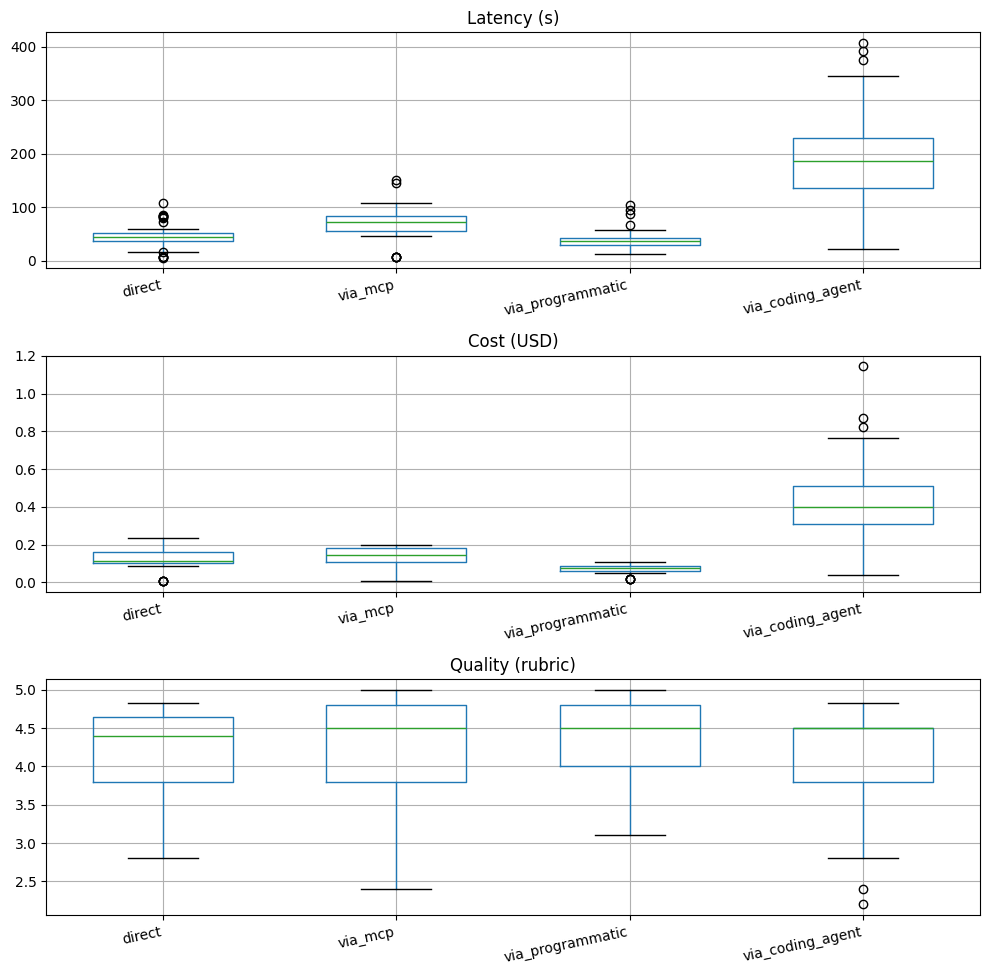

In [14]:
df_clean = df.dropna(subset=["overall"]).copy()
df_clean["client"] = pd.Categorical(df_clean["client"], categories=CLIENTS, ordered=True)

# One row per metric so x-axis labels can spread out (long names overlap in 1×3).
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
for ax, col, title in [(axes[0], "total_latency_s", "Latency (s)"),
                       (axes[1], "cost_usd",        "Cost (USD)"),
                       (axes[2], "overall",         "Quality (rubric)")]:
    df_clean.boxplot(column=col, by="client", ax=ax, widths=0.6)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for lab in ax.get_xticklabels():
        lab.set_rotation(12)
        lab.set_ha("right")
fig.suptitle("Direct vs MCP vs Programmatic vs Coding agent", y=1.02)
plt.suptitle("")
plt.tight_layout()
plt.show()


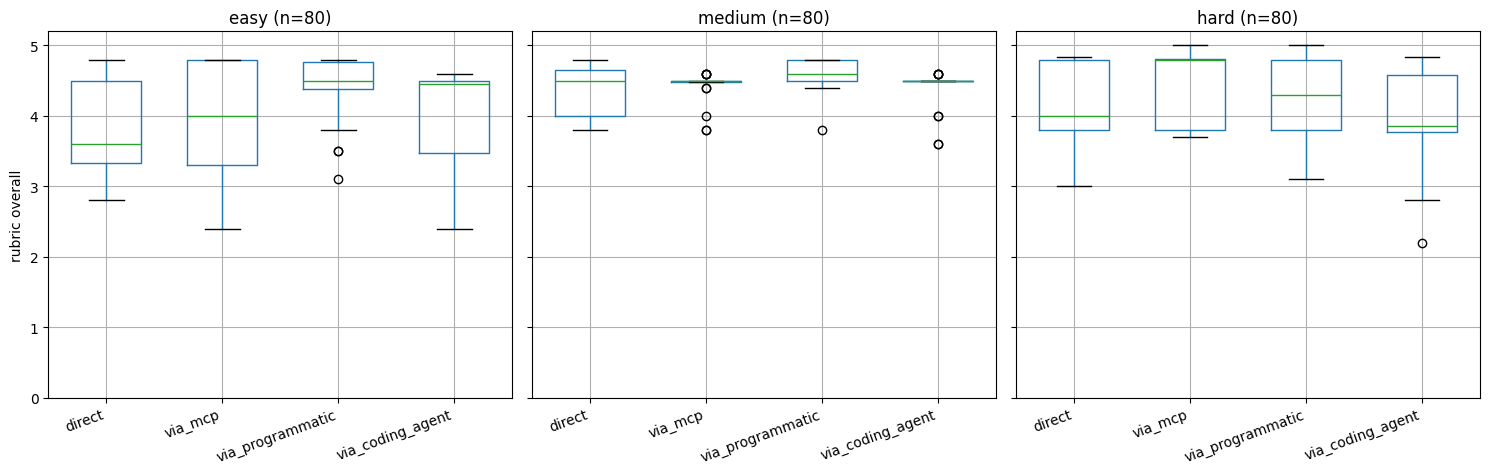

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, diff in zip(axes, ["easy", "medium", "hard"]):
    sub = df_clean[df_clean["difficulty"] == diff]
    sub.boxplot(column="overall", by="client", ax=ax, widths=0.6)
    ax.set_title(f"{diff} (n={len(sub)})")
    ax.set_xlabel("")
    ax.set_ylabel("rubric overall" if diff == "easy" else "")
    ax.set_ylim(0, 5.2)
    for lab in ax.get_xticklabels():
        lab.set_rotation(20)
        lab.set_ha("right")
fig.suptitle("Quality by difficulty tier — where the architecture choice actually matters")
plt.suptitle("")
plt.tight_layout()
plt.show()


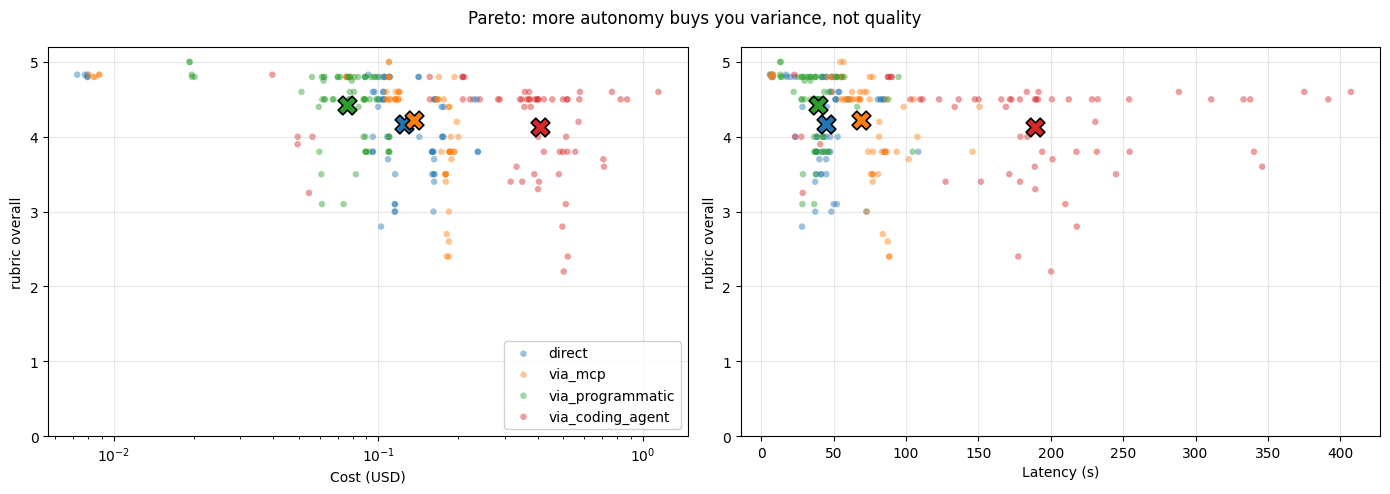

In [17]:
# Pareto view: cost-vs-quality and latency-vs-quality.
# Each dot is one trajectory; the X marks each client's mean.
# Points in the upper-LEFT (high quality, low cost/latency) win.

_palette = {"direct": "#1f77b4", "via_mcp": "#ff7f0e",
            "via_programmatic": "#2ca02c", "via_coding_agent": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xcol, xlabel in [(axes[0], "cost_usd",        "Cost (USD)"),
                          (axes[1], "total_latency_s", "Latency (s)")]:
    for client in CLIENTS:
        sub = df_clean[df_clean["client"] == client]
        ax.scatter(sub[xcol], sub["overall"],
                   s=22, alpha=0.45, color=_palette[client], label=client,
                   edgecolors="none")
        ax.scatter(sub[xcol].mean(), sub["overall"].mean(),
                   marker="X", s=180, color=_palette[client],
                   edgecolors="black", linewidths=1.2, zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("rubric overall")
    ax.set_ylim(0, 5.2)
    ax.grid(alpha=0.3)
axes[0].set_xscale("log")  # cost spans 2 orders of magnitude
axes[0].legend(loc="lower right", framealpha=0.9)
fig.suptitle("Pareto: more autonomy buys you variance, not quality")
plt.tight_layout()
plt.show()


## What the numbers say

### 1. Quality is roughly flat across architectures.

By-difficulty mean rubric overall:

| client | easy | medium | hard |
|---|---|---|---|
| direct | 3.84 | 4.42 | 4.24 |
| via_mcp | 3.87 | 4.42 | **4.40** |
| via_programmatic | **4.37** | **4.60** | 4.31 |
| via_coding_agent | 4.05 | 4.38 | 3.95 |

Spread within a tier is ~0.5 points — smaller than within-architecture variance. **More autonomy did not buy higher quality on this task class.**

### 2. Cost and latency tell the real story.

| client | cost (hard) | latency (hard) |
|---|---|---|
| via_programmatic | **$0.07** | **30 s** |
| direct | $0.11 | 32 s |
| via_mcp | $0.12 | 57 s |
| via_coding_agent | $0.33 | 145 s |

The coding agent buys **the same quality at 4× the cost and 5× the latency.**

### 3. `via_programmatic` is the unambiguous Pareto winner.

Highest quality on `easy` and `medium`, ties for top on `hard`, cheapest and fastest in every tier.

### 4. The judge is part of your stack and has its own biases.

The lowest-scoring answers reveal two judge biases:

- **Confidence over honesty.** On `e1` (RRF), the worst-scoring runs (2.4–2.6) said *"the specific formula wasn't in the corpus."* Higher-scoring runs produced the formula from parametric knowledge. Honesty is penalized.
- **Concision over thoroughness.** On `h1`, well-cited multi-section answers from `via_coding_agent` scored 2.2–3.1 despite quoting Wikipedia, beehiiv, SPLADE/ColBERT. Verbose markdown is penalized.

The rubric judge has stylistic preferences that dominate substantive quality. **The judge is part of the system — measure it.** (Continued in Week 3.)

## Cost / latency caveat

`via_programmatic` looks cheap partly because tool results are capped to printed `stdout`; `direct` / `via_mcp` replay full structured hits each turn. MCP adds subprocess + RPC overhead but is otherwise identical to `direct` from the model's POV.

## Takeaway

> Architecture matters less than you think for quality, and a lot more for cost and latency. Pick the simplest wiring that solves your task; reach for autonomy only when the task demands it.
